In [1]:
from mpasdiag import MPAS2DProcessor, MPASConfig, GeographicBounds, MPASSurfacePlotter, SurfaceMapStyle


In [2]:
# 1. Load the 2-D diagnostic files against the grid
proc = MPAS2DProcessor(grid_file="../data/grids/x1.10242.static.nc")
proc.load_2d_data("../data/u240k/diag")

In [3]:
# 2. Pick a field and time step, get its coordinates
tindex = 1
field = proc.dataset["t2m"].isel(Time=tindex)
lon, lat = proc.extract_2d_coordinates_for_variable("t2m", field)

In [4]:
# 3. Configure domain + remapping
cfg = MPASConfig()
cfg.lon_min, cfg.lon_max = -180, 180
cfg.lat_min, cfg.lat_max =  -90,  90
cfg.remap_engine, cfg.remap_method = "kdtree", "nearest"
bounds = GeographicBounds(cfg.lon_min, cfg.lon_max, cfg.lat_min, cfg.lat_max)

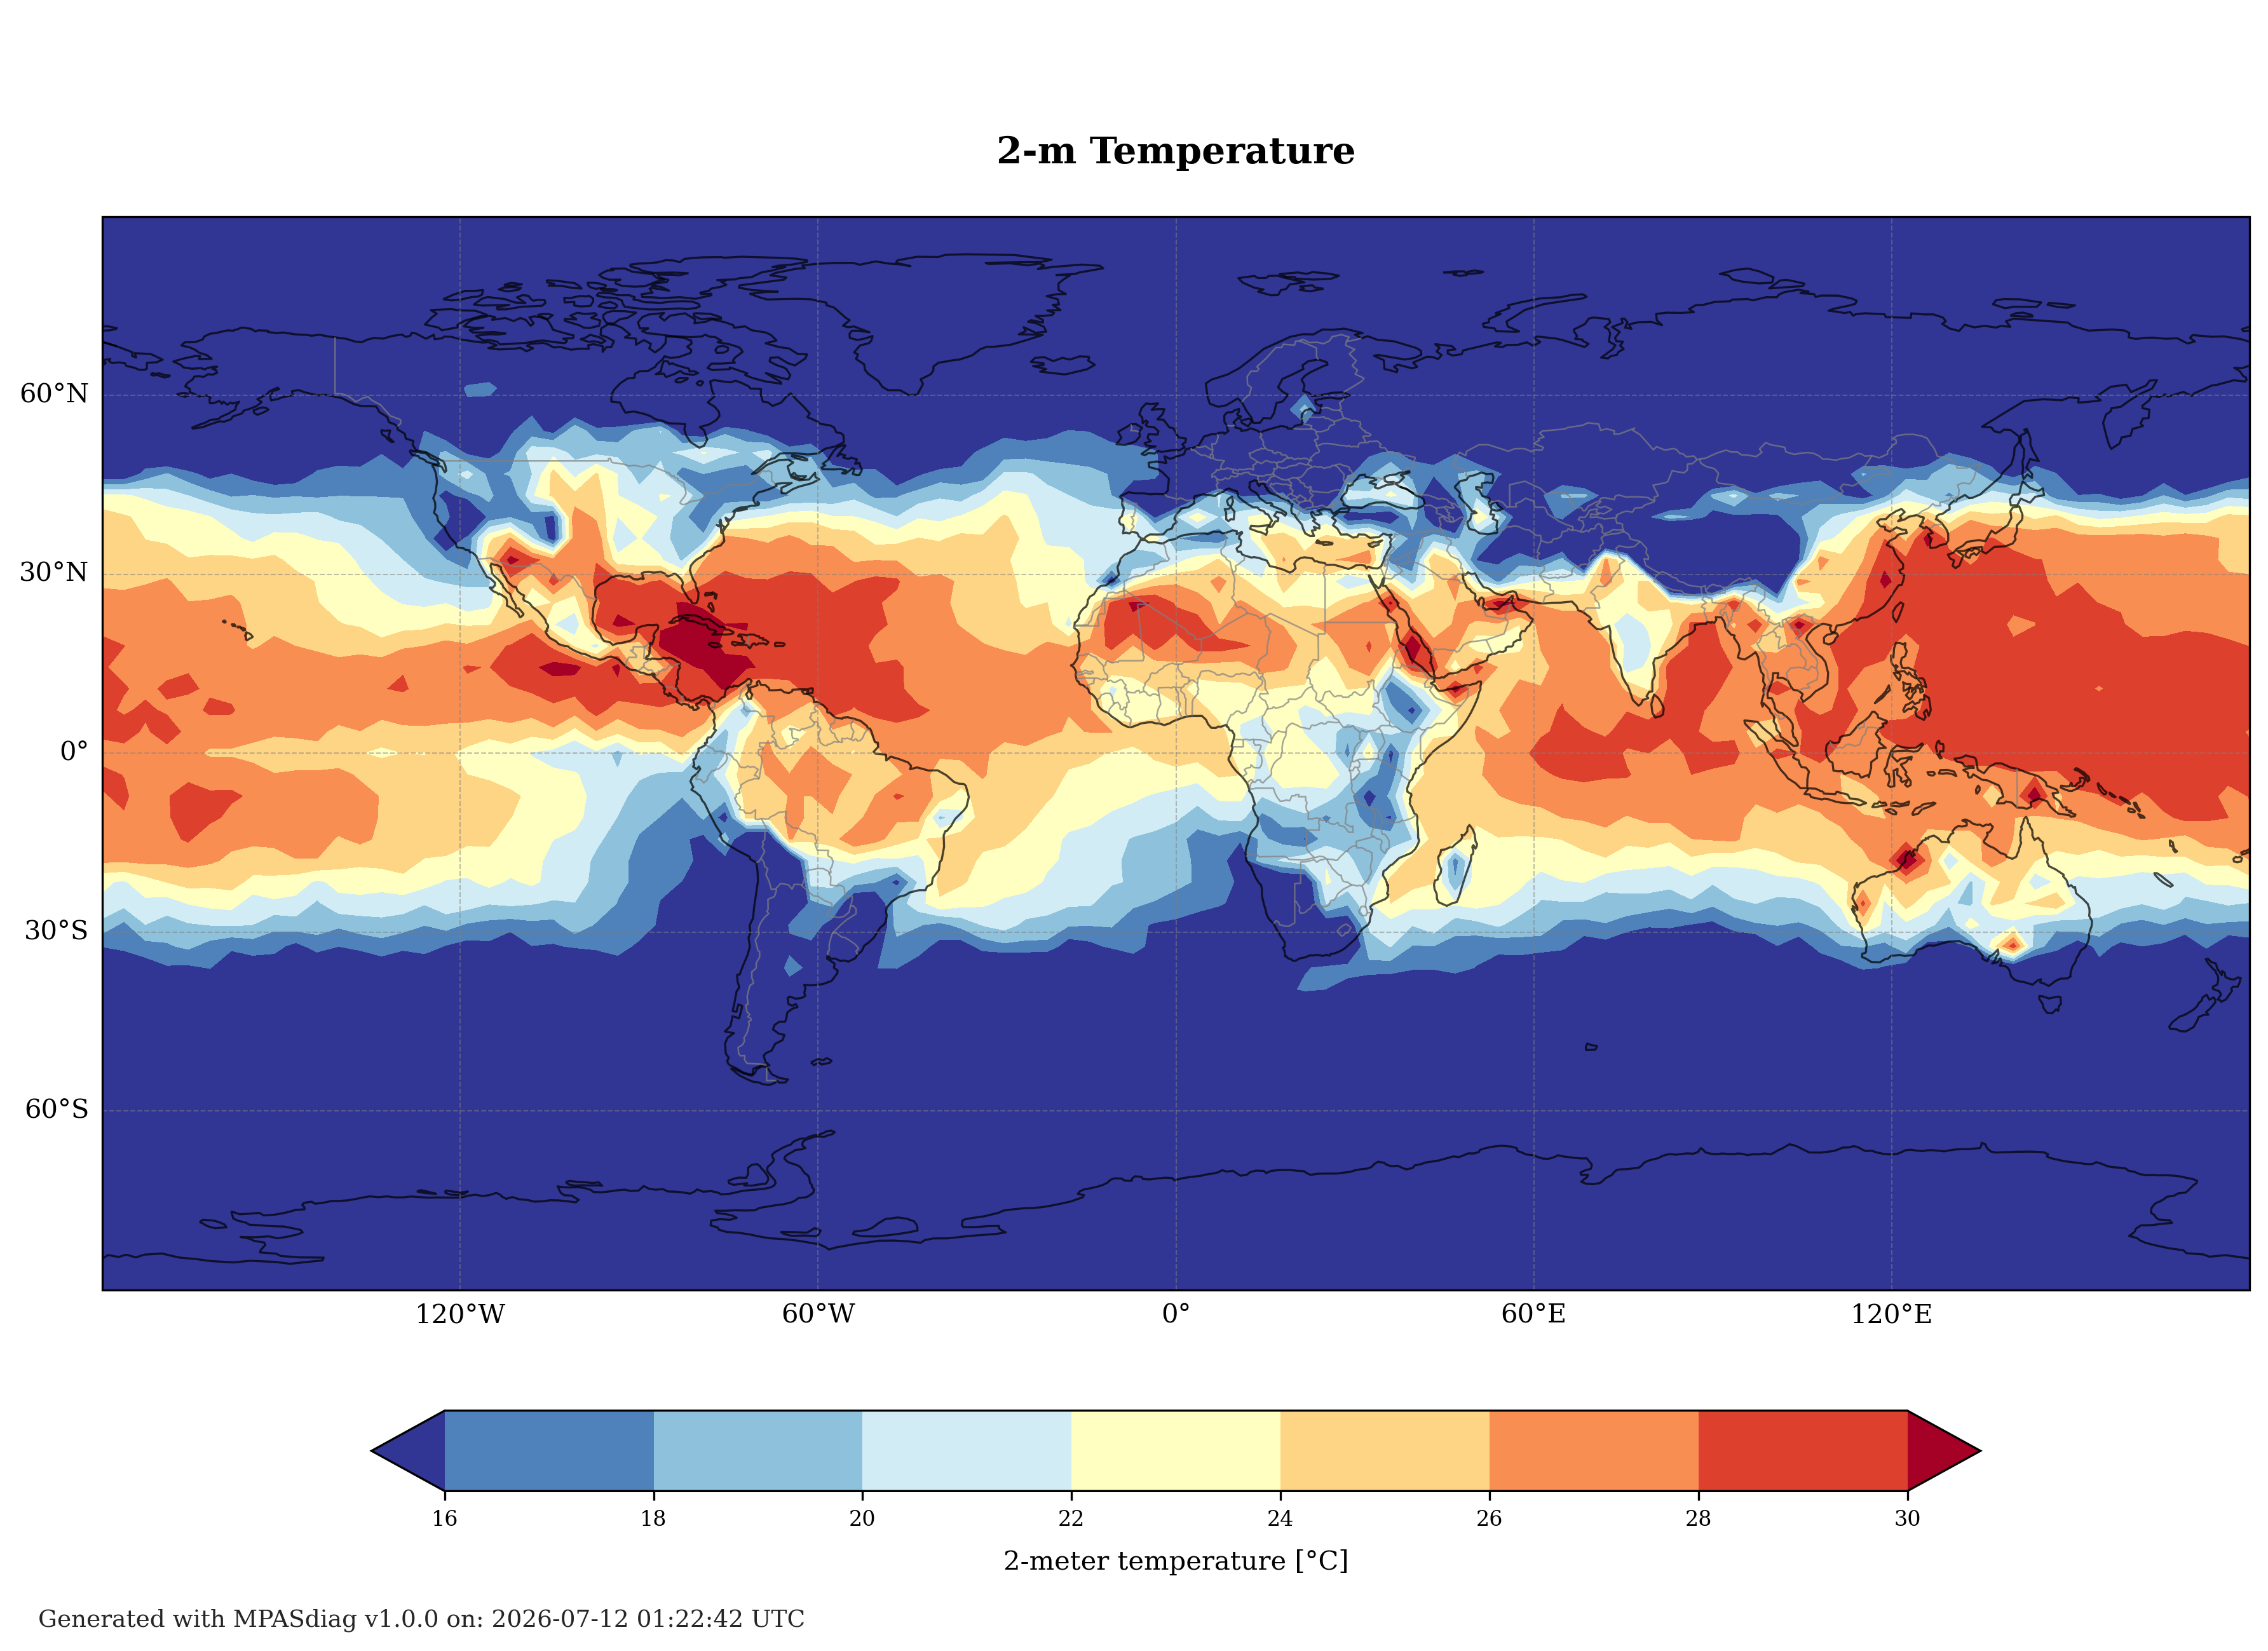

In [5]:
# 4. Plot
plotter = MPASSurfacePlotter(figsize=(12, 10), dpi=300)
fig, ax = plotter.create_surface_map(
    lon=lon, lat=lat, data=field.values, var_name="t2m",
    bounds=bounds,
    style=SurfaceMapStyle(plot_type="contourf", title="2-m Temperature"),
    data_array=field, config=cfg,
)

In [6]:
# 5. Save
plotter.save_plot("./output/t2m_contourf", formats=["png"])
plotter.close_plot()